In [ ]:
import pandas as pd
import json

In [57]:
with open('../data/raw/chennai.json',"r") as f:
    data=json.load(f)

In [58]:
df = pd.DataFrame({
    "hour": data["hourly"]["time"],
    "city": "Chennai",
    "latitude": data["latitude"],
    "longitude": data["longitude"],
    "temp": data["hourly"]["temperature_2m"],
    "wind_speed": data["hourly"]["wind_speed_10m"],
    "humidity": data["hourly"]["relative_humidity_2m"]
})

df["hour"] = pd.to_datetime(df["hour"])

df.head()

,hour,city,latitude,longitude,temp,wind_speed,humidity
0,2026-05-26 00:00:00,Chennai,13.110721,80.2459,29.9,10.7,77
1,2026-05-26 01:00:00,Chennai,13.110721,80.2459,30.1,8.9,75
2,2026-05-26 02:00:00,Chennai,13.110721,80.2459,31.6,9.7,67
3,2026-05-26 03:00:00,Chennai,13.110721,80.2459,34.2,13.9,52
4,2026-05-26 04:00:00,Chennai,13.110721,80.2459,36.0,12.3,46


In [59]:
df.dtypes

hour          datetime64[ns]
city                  object
latitude             float64
longitude            float64
temp                 float64
wind_speed           float64
humidity               int64
dtype: object

In [60]:
print(df.isnull().sum())

hour          0
city          0
latitude      0
longitude     0
temp          0
wind_speed    0
humidity      0
dtype: int64


In [61]:
df.isnull().values.any()

np.False_

In [62]:
df['date']=df['hour'].dt.date
df['hour']=df['hour'].dt.hour

In [63]:
df.head()

,hour,city,latitude,longitude,temp,wind_speed,humidity,date
0,0,Chennai,13.110721,80.2459,29.9,10.7,77,2026-05-26
1,1,Chennai,13.110721,80.2459,30.1,8.9,75,2026-05-26
2,2,Chennai,13.110721,80.2459,31.6,9.7,67,2026-05-26
3,3,Chennai,13.110721,80.2459,34.2,13.9,52,2026-05-26
4,4,Chennai,13.110721,80.2459,36.0,12.3,46,2026-05-26


In [64]:
df['date'].unique()

array([datetime.date(2026, 5, 26), datetime.date(2026, 5, 27),
       datetime.date(2026, 5, 28), datetime.date(2026, 5, 29),
       datetime.date(2026, 5, 30), datetime.date(2026, 5, 31),
       datetime.date(2026, 6, 1)], dtype=object)

In [65]:
max(df['temp'])

39.7

In [66]:
import pandas as pd

df["temp_category"] = pd.cut(
    df["temp"],
    bins=[0, 25, 32, 38, 100],
    labels=["Cool", "Medium", "Hot", "Extreme Hot"]
)

df[["temp", "temp_category"]].head()

,temp,temp_category
0,29.9,Medium
1,30.1,Medium
2,31.6,Medium
3,34.2,Hot
4,36.0,Hot


In [67]:
df.head()

,hour,city,latitude,longitude,temp,wind_speed,humidity,date,temp_category
0,0,Chennai,13.110721,80.2459,29.9,10.7,77,2026-05-26,Medium
1,1,Chennai,13.110721,80.2459,30.1,8.9,75,2026-05-26,Medium
2,2,Chennai,13.110721,80.2459,31.6,9.7,67,2026-05-26,Medium
3,3,Chennai,13.110721,80.2459,34.2,13.9,52,2026-05-26,Hot
4,4,Chennai,13.110721,80.2459,36.0,12.3,46,2026-05-26,Hot


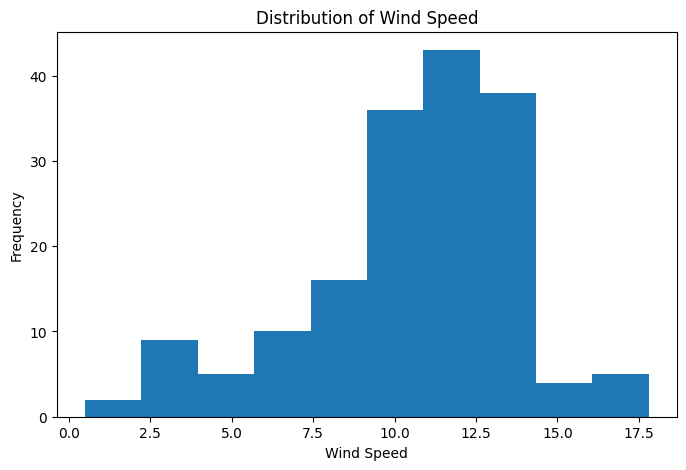

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["wind_speed"], bins=10)

plt.xlabel("Wind Speed")
plt.ylabel("Frequency")
plt.title("Distribution of Wind Speed")

plt.show()

In [69]:
df["wind_category"] = pd.cut(
    df["wind_speed"],
    bins=[0, 5, 10, 15, 100],
    labels=["Low", "Moderate", "High", "Very High"]
)

df[["wind_speed", "wind_category"]].head()

,wind_speed,wind_category
0,10.7,High
1,8.9,Moderate
2,9.7,Moderate
3,13.9,High
4,12.3,High


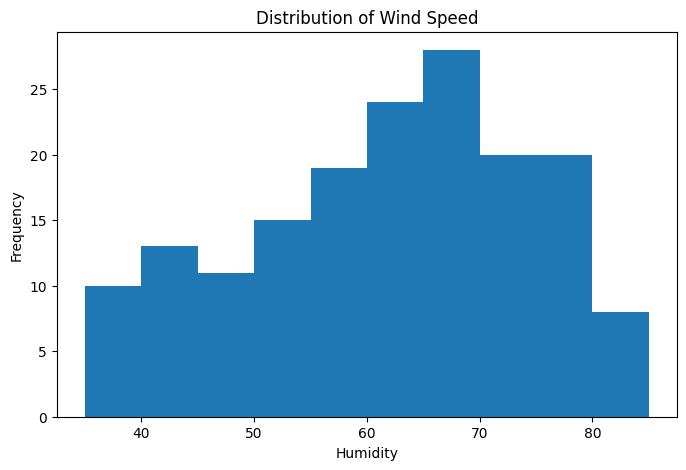

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["humidity"], bins=10)

plt.xlabel("Humidity")
plt.ylabel("Frequency")
plt.title("Distribution of Wind Speed")

plt.show()

In [71]:
df["humidity_category"] = pd.cut(
    df["humidity"],
    bins=[0, 30, 60, 80, 100],
    labels=["Low", "Moderate", "High", "Very High"]
)

df[["humidity", "humidity_category"]].head()

,humidity,humidity_category
0,77,High
1,75,High
2,67,High
3,52,Moderate
4,46,Moderate


In [72]:
df.head()

,hour,city,latitude,longitude,temp,wind_speed,humidity,date,temp_category,wind_category,humidity_category
0,0,Chennai,13.110721,80.2459,29.9,10.7,77,2026-05-26,Medium,High,High
1,1,Chennai,13.110721,80.2459,30.1,8.9,75,2026-05-26,Medium,Moderate,High
2,2,Chennai,13.110721,80.2459,31.6,9.7,67,2026-05-26,Medium,Moderate,High
3,3,Chennai,13.110721,80.2459,34.2,13.9,52,2026-05-26,Hot,High,Moderate
4,4,Chennai,13.110721,80.2459,36.0,12.3,46,2026-05-26,Hot,High,Moderate


In [73]:
df.duplicated().sum()

np.int64(0)

In [74]:
df.drop_duplicates(
    subset=["date", "hour", "city"],
    inplace=True
)

In [76]:
# Humidity should be between 0 and 100
assert df["humidity"].between(0,100).all(), \
    "Invalid humidity values found"

# Wind speed cannot be negative
assert df["wind_speed"].ge(0).all(), \
    "Invalid wind speed values found"

# Temperature realistic range
assert df["temp"].between(-50,60).all(), \
    "Invalid temperature values found"

In [77]:
df["temp"] = df["temp"].ffill()
df["humidity"] = df["humidity"].ffill()
df["wind_speed"] = df["wind_speed"].ffill()